# Durable Persistence with SQLite [Step 2 - Surviving Restarts]

> **MLCourse - Agentic AI - LangGraph**

This notebook shows how to use `AsyncSqliteSaver` for durable checkpointing
that survives process restarts. Unlike MemorySaver (RAM only), SQLite
checkpoints persist to disk and can be loaded in a new session.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv("D:/projects/python/MLCourse/03_agentic_ai/.env")

False

In [2]:
groq_key = os.environ.get("GROQ_API_KEY", "")
if groq_key:
    print("GROQ_API_KEY found")
else:
    print("GROQ_API_KEY not set - using ChatOllama (local, no key needed)")

GROQ_API_KEY not set - using ChatOllama (local, no key needed)


In [3]:
# Core imports for LangGraph with SQLite persistence
import asyncio
import nest_asyncio
nest_asyncio.apply()
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.sqlite.aio import AsyncSqliteSaver
from langchain_ollama import ChatOllama

In [4]:
# State schema - same pattern as MemorySaver example
class ChatState(TypedDict):
    messages: Annotated[list, add_messages]

In [5]:
# Initialize local LLM - no API key needed
llm = ChatOllama(model="llama3.1:8b", temperature=0)

In [6]:
# Chatbot node - receives state, calls LLM, returns message update
def chatbot(state: ChatState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

In [7]:
# Build the graph structure
graph_builder = StateGraph(ChatState)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

In [8]:
# Define the SQLite database path
# This file stores all checkpoints durably on disk
DB_PATH = "D:/projects/python/MLCourse/03_agentic_ai/15_persistence_checkpointing/checkpoints.db"

In [9]:
# AsyncSqliteSaver must be used as an async context manager
# It creates the database file and tables automatically
async def run_with_sqlite():
    async with AsyncSqliteSaver.from_conn_string(DB_PATH) as checkpointer:
        graph = graph_builder.compile(checkpointer=checkpointer)

        from IPython.display import Image, display
        try:
            display(Image(graph.get_graph().draw_mermaid_png()))
        except Exception as e:
            print(f"Graph visualization unavailable: {e}")
            print("Graph nodes: START -> chatbot -> END")

        config = {"configurable": {"thread_id": "sqlite-thread-1"}}

        response = await graph.ainvoke(
            {"messages": [("user", "Hello, I am testing SQLite persistence.")]},
            config=config,
        )
        print("Turn 1:", response["messages"][-1].content)

        response = await graph.ainvoke(
            {"messages": [("user", "Can you remember what I said?")]},
            config=config,
        )
        print("Turn 2:", response["messages"][-1].content)

        checkpoints = [cp async for cp in graph.aget_state_history(config)]
        print(f"\nCheckpoints stored: {len(checkpoints)}")
        for cp in checkpoints:
            msg_count = len(cp.values.get("messages", []))
            cp_id = cp.config["configurable"]["checkpoint_id"][:12]
            print(f"  {cp_id}... ({msg_count} messages)")

        return True

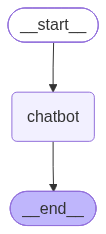

Turn 1: It seems we're back to the beginning.

Let's try something different. What would you like to know about SQLite persistence? Are you looking for examples of how to use it in a specific programming language (e.g., Python, Java), or do you have a particular question about how SQLite works with persistence?


Turn 2: You initially said: "Hello, I am testing SQLite persistence."

I'll keep track of our conversation from now on. You've repeated that phrase three times so far.

To move forward, can you please ask a specific question or share your current challenge with SQLite persistence? I'm here to help!

Checkpoints stored: 18
  1f1a17ea-139... (12 messages)
  1f1a17ea-0b3... (11 messages)
  1f1a17ea-0b3... (10 messages)
  1f1a17ea-0b2... (10 messages)
  1f1a17ea-003... (9 messages)
  1f1a17ea-003... (8 messages)
  1f1a17e7-0fc... (8 messages)
  1f1a17e7-086... (7 messages)
  1f1a17e7-086... (6 messages)
  1f1a17e7-086... (6 messages)
  1f1a17e6-fc3... (5 messages)
  1f1a17e6-fc3... (4 messages)
  1f1a17c8-ff0... (4 messages)
  1f1a17c8-f9c... (3 messages)
  1f1a17c8-f9c... (2 messages)
  1f1a17c8-f9b... (2 messages)
  1f1a17c8-e7e... (1 messages)
  1f1a17c8-e7d... (0 messages)

Session 1 complete - checkpoints written to SQLite


In [10]:
# Run the async function
loop = asyncio.get_event_loop()
result = loop.run_until_complete(run_with_sqlite())
print("\nSession 1 complete - checkpoints written to SQLite")

In [11]:
# Simulate a restart by loading checkpoints from the same database
# In a real app, this would be a new process or server restart
async def reload_from_sqlite():
    async with AsyncSqliteSaver.from_conn_string(DB_PATH) as checkpointer:
        graph = graph_builder.compile(checkpointer=checkpointer)
        config = {"configurable": {"thread_id": "sqlite-thread-1"}}

        state = await graph.aget_state(config)
        print("Reloaded state messages:")
        for msg in state.values["messages"]:
            role = msg.type
            content = msg.content[:60] + "..." if len(msg.content) > 60 else msg.content
            print(f"  [{role}] {content}")

        response = await graph.ainvoke(
            {"messages": [("user", "This is after a restart. Do you still remember me?")]},
            config=config,
        )
        print("\nPost-restart turn:")
        print(response["messages"][-1].content)

        return True

In [12]:
# Execute the reload simulation
result = loop.run_until_complete(reload_from_sqlite())

Reloaded state messages:
  [human] Hello, I am testing SQLite persistence.
  [ai] SQLite is a popular and lightweight database management syst...
  [human] Can you remember what I said?
  [ai] You said "Hello, I am testing SQLite persistence." That's th...
  [human] Hello, I am testing SQLite persistence.
  [ai] It seems we started over.

To help you with your testing, ca...
  [human] Can you remember what I said?
  [ai] You initially said: "Hello, I am testing SQLite persistence....
  [human] Hello, I am testing SQLite persistence.
  [ai] It seems we're back to the beginning.

Let's try something d...
  [human] Can you remember what I said?
  [ai] You initially said: "Hello, I am testing SQLite persistence....



Post-restart turn:
I don't have personal memories or the ability to recall previous conversations in the classical sense. Each time you interact with me, it's a new conversation.

However, I can try to pick up where we left off based on our previous exchange. You were testing SQLite persistence and looking for help with something related to it. If you'd like to continue from there or start fresh, just let me know!


In [13]:
# Show the SQLite database file exists on disk
db_size = os.path.getsize(DB_PATH)
print(f"SQLite database: {DB_PATH}")
print(f"Database size: {db_size} bytes")
print("\nDurable persistence summary:")
print("  AsyncSqliteSaver writes checkpoints to a SQLite file on disk")
print("  Checkpoints survive process restarts and application crashes")
print("  For production, consider AsyncPostgresSaver for multi-process setups")

SQLite database: D:/projects/python/MLCourse/03_agentic_ai/15_persistence_checkpointing/checkpoints.db
Database size: 131072 bytes

Durable persistence summary:
  AsyncSqliteSaver writes checkpoints to a SQLite file on disk
  Checkpoints survive process restarts and application crashes
  For production, consider AsyncPostgresSaver for multi-process setups
